# 股票涨跌分类 — 改进版

## 改进方向
| 原版问题 | 改进方案 |
|---------|---------|
| 训练/测试分布漂移 | **Purged Walk-Forward CV**（含 gap purging + embargo） |
| 技术指标滞后 | **特征增强**：量价背离、动量因子、波动率比、峰度偏度 |
| 预测周期太短噪声大 | **未来 20 日**方向（从 5 日→20 日） |
| 噪声标签干扰 | **分位数过滤**：仅保留 top/bottom 30% 涨跌样本 |
| 单次切分不稳健 | **5 折滚动窗口**验证，评估指标取均值 |

---

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
import xgboost as xgb
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, roc_auc_score, confusion_matrix,
                             roc_curve)
from sklearn.model_selection import TimeSeriesSplit
from sklearn.inspection import permutation_importance

plt.rcParams['font.sans-serif'] = ['SimHei', 'Microsoft YaHei', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False

OUTPUT_DIR = Path("D:/online internship/Task-5")
for d in ['predictions', 'metrics', 'figures']:
    (OUTPUT_DIR / d).mkdir(exist_ok=True)
print(f"输出目录: {OUTPUT_DIR}")

print("✅ 导入完成")

输出目录: D:\online internship\Task-5
✅ 导入完成


In [2]:
DATA_PATH = Path("D:/online internship/Task-3/兆易创新_daily.csv")
df = pd.read_csv(DATA_PATH)
df['trade_date'] = pd.to_datetime(df['trade_date'])
df.sort_values('trade_date', ascending=True, inplace=True)
df.reset_index(drop=True, inplace=True)

print(f"数据形状: {df.shape}")
print(f"时间范围: {df['trade_date'].min()} ~ {df['trade_date'].max()}")
df.head(3)

数据形状: (1091, 11)
时间范围: 2022-01-04 00:00:00 ~ 2026-07-08 00:00:00


,ts_code,trade_date,open,high,low,close,pre_close,change,pct_chg,vol,amount
0,603986.SH,2022-01-04,176.56,178.90,171.01,175.88,175.85,0.03,0.0171,108741.97,1900824.345
1,603986.SH,2022-01-05,174.77,174.77,158.29,158.30,175.88,-17.58,-9.9955,256634.97,4158864.709
2,603986.SH,2022-01-06,155.00,167.80,154.60,162.96,158.30,4.66,2.9438,164935.26,2658078.307


## 探索性数据分析 (EDA)

在特征工程之前，先了解数据的基本情况：价格走势、成交量分布、涨跌比例等。

📊 数据概览
交易日数: 1091
时间范围: 2022-01-04 00:00:00 ~ 2026-07-08 00:00:00
年化交易日: 242 天/年



findfont: Failed to find font weight bold, now using 400.


findfont: Failed to find font weight bold, now using 400.


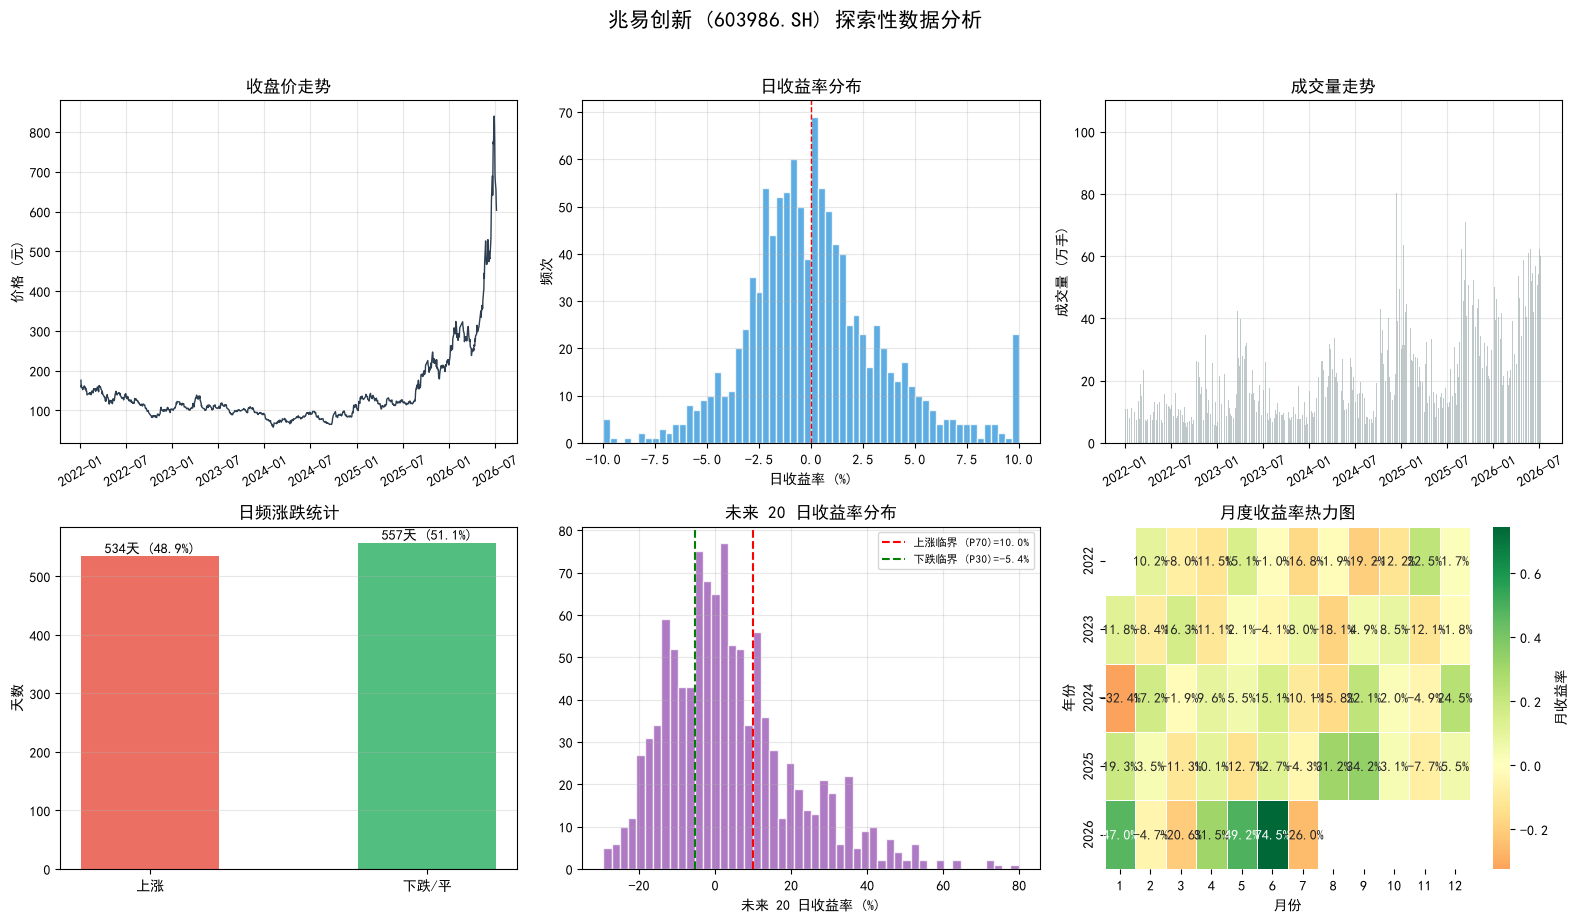


📈 关键统计量

统计项                             值
----------------------------------
起始日                  2022-01-04 00:00:00
结束日                  2026-07-08 00:00:00
总交易日                         1091
收盘价均值                    144.81 元
收盘价标准差                   100.77 元
收盘价最高                    840.00 元
收盘价最低                     57.92 元

涨跌统计                       天数       占比
--------------------------------------
上涨天数                      534   48.9%
下跌/平天数                    557   51.1%
涨跌比                    0.959

日均收益率                   +0.1699%
日收益率标准差                  3.3472%
年化收益率                    +42.82%
年化波动率                     53.13%
夏普比率                       0.806


In [3]:
# =====================================================
#  EDA: 数据探索性分析
# =====================================================
print("=" * 55)
print("📊 数据概览")
print("=" * 55)
print(f"交易日数: {len(df)}")
print(f"时间范围: {df['trade_date'].min()} ~ {df['trade_date'].max()}")
print(f"年化交易日: {len(df) / ((df['trade_date'].max() - df['trade_date'].min()).days / 365):.0f} 天/年")
print()

# --- 价格走势 ---
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
fig.suptitle('兆易创新 (603986.SH) 探索性数据分析', fontsize=15, fontweight='bold', y=1.02)

# 1. 收盘价走势
ax = axes[0, 0]
ax.plot(df['trade_date'], df['close'], color='#2C3E50', lw=1)
ax.set_title('收盘价走势', fontsize=12, fontweight='bold')
ax.set_ylabel('价格 (元)')
ax.tick_params(axis='x', rotation=30)
ax.grid(True, alpha=0.3)

# 2. 日收益率分布
ax = axes[0, 1]
returns = df['close'] / df['pre_close'] - 1
ax.hist(returns * 100, bins=60, color='#3498DB', edgecolor='white', alpha=0.8)
ax.axvline(0, color='red', ls='--', lw=1)
ax.set_title('日收益率分布', fontsize=12, fontweight='bold')
ax.set_xlabel('日收益率 (%)')
ax.set_ylabel('频次')
ax.grid(True, alpha=0.3)

# 3. 成交量走势
ax = axes[0, 2]
ax.bar(df['trade_date'], df['vol'] / 1e4, color='#95A5A6', width=1, alpha=0.6)
ax.set_title('成交量走势', fontsize=12, fontweight='bold')
ax.set_ylabel('成交量 (万手)')
ax.tick_params(axis='x', rotation=30)
ax.grid(True, alpha=0.3)

# 4. 涨跌天数统计 (基于日收益率)
ax = axes[1, 0]
up_days = (returns > 0).sum()
dn_days = (returns <= 0).sum()
bars = ax.bar(['上涨', '下跌/平'], [up_days, dn_days],
              color=['#E74C3C', '#27AE60'], alpha=0.8, width=0.5)
for bar, label in zip(bars, [f"{up_days}天 ({up_days/len(df):.1%})", f"{dn_days}天 ({dn_days/len(df):.1%})"]):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 2, label, ha="center", va="bottom", fontsize=10)
ax.set_title('日频涨跌统计', fontsize=12, fontweight='bold')
ax.set_ylabel('天数')
ax.grid(axis='y', alpha=0.3)

# 5. 未来 20 日收益率分布（标签构造的基础）
ax = axes[1, 1]
fwd20 = df['close'].shift(-20) / df['close'] - 1
fwd20_valid = fwd20.dropna()
ax.hist(fwd20_valid * 100, bins=50, color='#9B59B6', edgecolor='white', alpha=0.8)
up_th = fwd20_valid.quantile(0.70)
dn_th = fwd20_valid.quantile(0.30)
ax.axvline(up_th*100, color='red', ls='--', lw=1.5, label=f'上涨临界 (P70)={up_th:.1%}')
ax.axvline(dn_th*100, color='green', ls='--', lw=1.5, label=f'下跌临界 (P30)={dn_th:.1%}')
ax.set_title('未来 20 日收益率分布', fontsize=12, fontweight='bold')
ax.set_xlabel('未来 20 日收益率 (%)')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

# 6. 月均收益率热力图
ax = axes[1, 2]
df_plot = df.copy()
df_plot['year'] = df_plot['trade_date'].dt.year
df_plot['month'] = df_plot['trade_date'].dt.month
monthly_ret = df_plot.groupby(['year', 'month'])['close'].last().pct_change()
monthly_ret = monthly_ret.groupby(['year', 'month']).first().dropna().unstack()
sns.heatmap(monthly_ret, cmap='RdYlGn', center=0, annot=True, fmt='.1%',
            ax=ax, cbar_kws={'label': '月收益率'}, linewidths=0.5)
ax.set_title('月度收益率热力图', fontsize=12, fontweight='bold')
ax.set_ylabel('年份')
ax.set_xlabel('月份')

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'figures' / 'eda_overview.png', dpi=150, bbox_inches='tight')
plt.show()

# --- 关键统计量输出 ---
print()
print("=" * 55)
print("📈 关键统计量")
print("=" * 55)
print(f"\n{'统计项':<20s} {'值':>12s}")
print("-" * 34)
print(f"{'起始日':<20s} {str(df['trade_date'].min()):>12s}")
print(f"{'结束日':<20s} {str(df['trade_date'].max()):>12s}")
print(f"{'总交易日':<20s} {len(df):>12d}")
print(f"{'收盘价均值':<20s} {df['close'].mean():>10.2f} 元")
print(f"{'收盘价标准差':<20s} {df['close'].std():>10.2f} 元")
print(f"{'收盘价最高':<20s} {df['close'].max():>10.2f} 元")
print(f"{'收盘价最低':<20s} {df['close'].min():>10.2f} 元")

print(f"\n{'涨跌统计':<20s} {'天数':>8s} {'占比':>8s}")
print("-" * 38)
print(f"{'上涨天数':<20s} {up_days:>8d} {up_days/len(df):>7.1%}")
print(f"{'下跌/平天数':<20s} {dn_days:>8d} {dn_days/len(df):>7.1%}")
print(f"{'涨跌比':<20s} {up_days/dn_days:>7.3f}")

print(f"\n{'日均收益率':<20s} {returns.mean():>+11.4%}")
print(f"{'日收益率标准差':<20s} {returns.std():>11.4%}")
print(f"{'年化收益率':<20s} {returns.mean()*252:>+11.2%}")
print(f"{'年化波动率':<20s} {returns.std()*np.sqrt(252):>11.2%}")
print(f"{'夏普比率':<20s} {returns.mean()/returns.std()*np.sqrt(252):>11.3f}")


## 特征工程（增强版）

在原版基础上新增：
- **量价背离信号**: 价格涨但成交量萎缩 → 上涨乏力
- **动量因子**: 20 日动量 ÷ 波动率（Carhart 风格动量）
- **相对强度**: 价格偏离 60 日均线的程度
- **波动率比**: 短期波动率 / 长期波动率 → 捕捉波动率结构变化
- **偏度 & 峰度**: 收益率分布的高阶矩特征

In [4]:
def build_features_enhanced(df_orig):
    df = df_orig.copy()

    # --- 原版特征 ---
    df['returns_1d'] = df['close'] / df['pre_close'] - 1
    df['returns_5d'] = df['close'] / df['close'].shift(5) - 1
    df['returns_10d'] = df['close'] / df['close'].shift(10) - 1
    df['returns_20d'] = df['close'] / df['close'].shift(20) - 1
    df['high_low_ratio'] = (df['high'] - df['low']) / df['close']
    df['close_open_ratio'] = (df['close'] - df['open']) / df['open']

    for n in [5, 10, 20, 60]:
        df[f'ma{n}'] = df['close'].rolling(n).mean()
    df['ma20_ratio'] = df['close'] / df['ma20'] - 1
    df['ma5_ma20_cross'] = df['close'].rolling(5).mean() / df['ma20'] - 1

    df['std_20'] = df['close'].rolling(20).std()

    tr = pd.concat([
        df['high'] - df['low'],
        (df['high'] - df['close'].shift(1)).abs(),
        (df['low'] - df['close'].shift(1)).abs()
    ], axis=1).max(axis=1)
    df['atr_14'] = tr.rolling(14).mean()

    df['bb_mid'] = df['close'].rolling(20).mean()
    bb_std = df['close'].rolling(20).std()
    df['bb_upper'] = df['bb_mid'] + 2 * bb_std
    df['bb_lower'] = df['bb_mid'] - 2 * bb_std
    df['bb_width'] = (df['bb_upper'] - df['bb_lower']) / df['bb_mid']

    delta = df['close'].diff()
    gain = delta.clip(lower=0).rolling(14).mean()
    loss = (-delta.clip(upper=0)).rolling(14).mean()
    rs = gain / loss.replace(0, np.nan)
    df['rsi_14'] = 100 - (100 / (1 + rs))

    ema12 = df['close'].ewm(span=12).mean()
    ema26 = df['close'].ewm(span=26).mean()
    df['macd'] = ema12 - ema26
    df['macd_signal'] = df['macd'].ewm(span=9).mean()
    df['macd_hist'] = df['macd'] - df['macd_signal']

    obv = (df['vol'] * np.sign(df['close'] - df['pre_close'])).fillna(0).cumsum()
    df['obv'] = obv
    df['volume_ma5_ratio'] = df['vol'] / df['vol'].rolling(5).mean()

    # --- 新增: 量价背离 ---
    # 价格涨但成交量相对萎缩 = 背离信号 (负值表示量价齐升, 正值表示量价背离)
    vol_ratio = df['vol'] / df['vol'].rolling(20).mean()
    df['volume_price_div'] = df['returns_1d'] * (vol_ratio - 1)
    # 负值: 上涨时量也放大(正常), 正值: 上涨时量萎缩(背离=危险信号)

    # --- 新增: 动量因子 (Carhart 风格, 动量/波动率) ---
    mom_20 = df['close'] / df['close'].shift(20) - 1
    vol_20 = df['close'].pct_change().rolling(20).std()
    df['momentum_factor'] = mom_20 / vol_20.replace(0, np.nan)

    # --- 新增: 相对强度 (价格 vs 60日均线) ---
    df['relative_strength'] = df['close'] / df['ma60'] - 1

    # --- 新增: 波动率比 (5日 / 60日) ---
    pct_chg = df['close'].pct_change()
    vol_5 = pct_chg.rolling(5).std()
    vol_60 = pct_chg.rolling(60).std()
    df['volatility_ratio'] = vol_5 / vol_60.replace(0, np.nan)

    # --- 新增: 偏度 & 峰度 (收益率分布高阶矩) ---
    df['skew_20'] = df['returns_1d'].rolling(20).skew()
    df['kurt_20'] = df['returns_1d'].rolling(20).kurt()

    # --- 滞后特征 ---
    for col in ['returns_1d', 'rsi_14', 'macd_hist', 'atr_14', 'volume_price_div', 'momentum_factor']:
        for lag in [1]:
            df[f'{col}_lag{lag}'] = df[col].shift(lag)

    return df

df_feat = build_features_enhanced(df)
feature_cols = [c for c in df_feat.columns if c not in [
    'ts_code', 'trade_date', 'open', 'high', 'low', 'close', 'pre_close',
    'change', 'pct_chg', 'vol', 'amount'
]]
print(f"特征总数: {len(feature_cols)}")
print(f"精简后特征: 去除了 momentum_5, turnover_rate, 冗余均线/波动率, lag 从 3 减为 1")

特征总数: 36
精简后特征: 去除了 momentum_5, turnover_rate, 冗余均线/波动率, lag 从 3 减为 1


## 标签构造（改进版）

- **预测周期**: 未来 20 日（方向比 5 日更稳定）
- **分位数过滤**: 仅保留未来收益率 top 30%（涨）和 bottom 30%（跌），中间 40% 的弱信号丢弃
- 目的是让模型学习**确定性更高的涨跌信号**，而非噪声中的随机涨跌

In [5]:
# 未来 20 日收益率
df_feat['returns_fwd_20'] = df_feat['close'].shift(-20) / df_feat['close'] - 1

# 分位数过滤: top 30% = 涨(1), bottom 30% = 跌(0)
up_th = df_feat['returns_fwd_20'].quantile(0.70)
dn_th = df_feat['returns_fwd_20'].quantile(0.30)

df_feat['direction_fwd_20'] = np.nan
df_feat.loc[df_feat['returns_fwd_20'] > up_th, 'direction_fwd_20'] = 1
df_feat.loc[df_feat['returns_fwd_20'] < dn_th, 'direction_fwd_20'] = 0

print(f"分位阈值: 下跌临界={dn_th:.4%}, 上涨临界={up_th:.4%}")
print(f"原始样本: {len(df_feat)}")

# 丢弃中间 40% + 标签 NaN 行 + 特征 NaN 行
df_labeled = df_feat.dropna(subset=['direction_fwd_20']).copy()
initial = len(df_labeled)
df_labeled = df_labeled.dropna()
print(f"丢弃 NaN 行: {initial - len(df_labeled)}")
print(f"保留样本: {len(df_labeled)}")
print(f"\n标签分布:")
print(df_labeled['direction_fwd_20'].value_counts().to_string())
print(f"\n涨比例: {df_labeled['direction_fwd_20'].mean():.2%}")

分位阈值: 下跌临界=-5.4064%, 上涨临界=10.0391%
原始样本: 1091
丢弃 NaN 行: 38
保留样本: 604

标签分布:
direction_fwd_20
1.0    315
0.0    289

涨比例: 52.15%


## 特征相关性分析

特征之间的相关性、以及与目标变量（未来 20 日涨跌）的关系分析。

### 两张图
1. **特征相关性热力图** — 发现高度相关的冗余特征对
2. **Top 10 与目标最相关特征** — 哪些特征对涨跌预测最有信息量

findfont: Failed to find font weight bold, now using 400.


参与相关性分析的特征数: 36


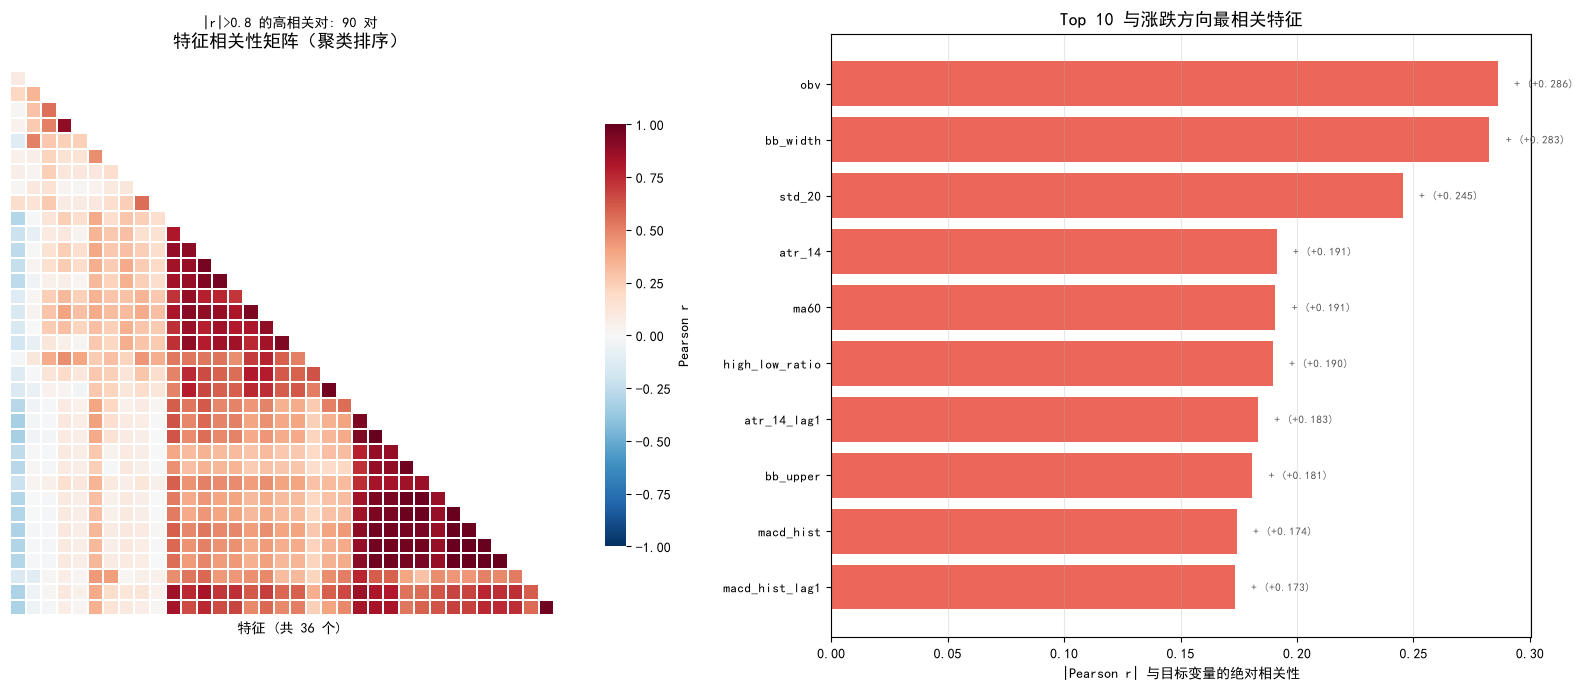

✔ 特征相关性图已保存


In [6]:
# =====================================================
#  特征相关性分析
# =====================================================
from scipy.cluster import hierarchy

corr_exclude = {'ts_code', 'trade_date', 'open', 'high', 'low', 'close',
                'pre_close', 'change', 'pct_chg', 'vol', 'amount',
                'returns_fwd_20', 'direction_fwd_20'}
corr_feat_cols = [c for c in df_labeled.columns if c not in corr_exclude]
corr_data = df_labeled[corr_feat_cols].copy()
corr_data = corr_data.loc[:, corr_data.std() > 1e-10]

print(f"参与相关性分析的特征数: {len(corr_data.columns)}")

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# --- 图1: 特征相关性矩阵 ---
corr_matrix = corr_data.corr(method='pearson')
corr_linkage = hierarchy.ward(corr_matrix.values)
corr_order = hierarchy.leaves_list(corr_linkage)
corr_sorted = corr_matrix.iloc[corr_order, corr_order]

mask = np.zeros_like(corr_sorted, dtype=bool)
mask[np.triu_indices_from(mask)] = True

ax = axes[0]
sns.heatmap(corr_sorted, mask=mask, cmap='RdBu_r', center=0,
            vmin=-1, vmax=1, square=True, linewidths=0.3,
            cbar_kws={"shrink": 0.7, "label": "Pearson r"},
            xticklabels=False, yticklabels=False, ax=ax)
ax.set_title("特征相关性矩阵（聚类排序）", fontsize=13, fontweight='bold')
ax.set_xlabel("特征 (共 " + str(len(corr_data.columns)) + " 个)")
high_corr = (corr_matrix.abs().values[np.triu_indices_from(corr_matrix.values, k=1)] > 0.8).sum()
ax.text(0.5, 1.05, f"|r|>0.8 的高相关对: {high_corr} 对", transform=ax.transAxes, ha='center', fontsize=10)

# --- 图2: Top 10 与目标最相关特征 ---
target = df_labeled['direction_fwd_20']
corr_with_target = corr_data.apply(lambda x: x.corr(target)).abs().sort_values(ascending=False)

ax = axes[1]
top10 = corr_with_target.head(10)
actual_corrs = [corr_data[c].corr(target) for c in top10.index]
colors_bar = ['#E74C3C' if r > 0 else '#3498DB' for r in actual_corrs]
ax.barh(range(len(top10)), top10.values, color=colors_bar, alpha=0.85)
ax.set_yticks(range(len(top10)))
ax.set_yticklabels(top10.index, fontsize=9)
ax.set_xlabel("|Pearson r| 与目标变量的绝对相关性", fontsize=10)
ax.set_title("Top 10 与涨跌方向最相关特征", fontsize=13, fontweight='bold')
ax.invert_yaxis()
ax.grid(axis='x', alpha=0.3)

for i, (c, v) in enumerate(top10.items()):
    actual_r = actual_corrs[i]
    sign = "+" if actual_r > 0 else "-"
    ax.text(v + 0.002, i, f"  {sign} ({actual_r:+.3f})",
             va='center', fontsize=8, color='#555')

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'figures' / 'feature_correlation.png', dpi=150, bbox_inches='tight')
plt.show()
print("✔ 特征相关性图已保存")

## Purged Walk-Forward Cross-Validation

使用 sklearn 的 `TimeSeriesSplit` 进行 5 折滚动验证：
- **gap=20**：相邻训练/测试集之间留 20 天缓冲（purging），避免未来数据泄露
- **expanding window**：每折训练集逐步扩大，测试集为后续固定窗口
- **embargo**：通过 gap 参数实现 embargo 效应

评估指标取 5 折均值，比单次切分更稳健。

In [7]:
# 准备特征矩阵
X_cols = [c for c in df_labeled.columns if c not in {
    'ts_code', 'trade_date', 'open', 'high', 'low', 'close',
    'pre_close', 'change', 'pct_chg', 'vol', 'amount',
    'returns_fwd_20', 'direction_fwd_20'
}]
X = df_labeled[X_cols].values
y = df_labeled['direction_fwd_20'].values.astype(int)
dates = df_labeled['trade_date'].values

print(f"特征矩阵: {X.shape}")
print(f"特征列数: {len(X_cols)}")

# Purged Walk-Forward CV (5折, gap=20 实现 purging)
N_SPLITS = 5
GAP = 20
tscv = TimeSeriesSplit(n_splits=N_SPLITS, gap=GAP)

fold_sizes = []
for fold, (train_idx, test_idx) in enumerate(tscv.split(X)):
    fold_sizes.append((len(train_idx), len(test_idx)))
    print(f"Fold {fold+1}: 训练 {len(train_idx)} 条 ({dates[train_idx][0]} ~ {dates[train_idx][-1]}) "          f"→ 测试 {len(test_idx)} 条 ({dates[test_idx][0]} ~ {dates[test_idx][-1]})")
print(f"\n每折测试集大小: {[s[1] for s in fold_sizes]}")

特征矩阵: (604, 36)
特征列数: 36
Fold 1: 训练 84 条 (2022-04-07T00:00:00.000000 ~ 2022-11-07T00:00:00.000000) → 测试 100 条 (2023-01-09T00:00:00.000000 ~ 2023-12-06T00:00:00.000000)
Fold 2: 训练 184 条 (2022-04-07T00:00:00.000000 ~ 2023-08-28T00:00:00.000000) → 测试 100 条 (2023-12-07T00:00:00.000000 ~ 2024-08-02T00:00:00.000000)
Fold 3: 训练 284 条 (2022-04-07T00:00:00.000000 ~ 2024-07-05T00:00:00.000000) → 测试 100 条 (2024-08-05T00:00:00.000000 ~ 2025-03-10T00:00:00.000000)
Fold 4: 训练 384 条 (2022-04-07T00:00:00.000000 ~ 2024-12-26T00:00:00.000000) → 测试 100 条 (2025-03-11T00:00:00.000000 ~ 2025-12-08T00:00:00.000000)
Fold 5: 训练 484 条 (2022-04-07T00:00:00.000000 ~ 2025-10-21T00:00:00.000000) → 测试 100 条 (2025-12-09T00:00:00.000000 ~ 2026-06-09T00:00:00.000000)

每折测试集大小: [100, 100, 100, 100, 100]


## 模型训练 — 5 折滚动验证

对每个模型在每个 fold 上：
1. 标准化（LR/SVC 需要，RF/XGB 跳过）
2. 训练 → 预测 → 计算指标
3. 最终报告 5 折均值 ± 标准差

In [8]:
classifiers = [
    ('逻辑回归 (LR)', LogisticRegression(C=1.0, penalty='l2', solver='lbfgs',
                                          class_weight='balanced', max_iter=2000, random_state=42), True),
    ('随机森林 (RF)', RandomForestClassifier(n_estimators=200, max_depth=8,
                                              min_samples_leaf=10, class_weight='balanced',
                                              random_state=42), False),
    ('XGBoost', xgb.XGBClassifier(n_estimators=200, max_depth=4, learning_rate=0.05,
                                   subsample=0.8, scale_pos_weight=1,
                                   eval_metric='logloss', random_state=42, verbosity=0), False),
    ('支持向量机 (SVC)', SVC(kernel='linear', C=1.0,
                              class_weight='balanced', probability=True, random_state=42), True),
]

def evaluate_fold(clf, X_tr, y_tr, X_te, y_te, do_scale):
    """单折训练评估"""
    scaler = StandardScaler() if do_scale else None
    if scaler:
        X_tr = scaler.fit_transform(X_tr)
        X_te = scaler.transform(X_te)
    clf.fit(X_tr, y_tr)
    y_pred = clf.predict(X_te)
    try:
        y_prob = clf.predict_proba(X_te)[:, 1]
    except AttributeError:
        y_prob = np.full_like(y_pred, np.nan, dtype=float)
    metrics = {
        'Accuracy': accuracy_score(y_te, y_pred),
        'Precision': precision_score(y_te, y_pred, zero_division=0),
        'Recall': recall_score(y_te, y_pred, zero_division=0),
        'F1': f1_score(y_te, y_pred, zero_division=0),
        'AUC': roc_auc_score(y_te, y_prob) if not np.isnan(y_prob).all() else np.nan,
    }
    return y_pred, y_prob, metrics, clf, scaler

# 收集所有折的结果
all_results = {name: {'fold_metrics': [], 'preds': [], 'probs': [], 'models': []}
               for name, _, _ in classifiers}

for fold, (train_idx, test_idx) in enumerate(tscv.split(X)):
    X_tr, y_tr = X[train_idx], y[train_idx]
    X_te, y_te = X[test_idx], y[test_idx]
    print(f"\n{'='*50}")
    print(f"Fold {fold+1}/{N_SPLITS}")

    for name, clf, do_scale in classifiers:
        y_pred, y_prob, metrics, model, scaler = evaluate_fold(
            clf, X_tr, y_tr, X_te, y_te, do_scale)
        all_results[name]['fold_metrics'].append(metrics)
        all_results[name]['preds'].append(y_pred)
        all_results[name]['probs'].append(y_prob)
        all_results[name]['models'].append(model)
        print(f"  {name:<18s} Acc={metrics['Accuracy']:.3f}  P={metrics['Precision']:.3f}  "
              f"R={metrics['Recall']:.3f}  F1={metrics['F1']:.3f}  AUC={metrics['AUC']:.3f}")

# 汇总 5 折均值
print(f"\n{'='*60}")
print("📋 5 折交叉验证汇总 (均值 ± 标准差)")
print(f"{'='*60}")

summary_rows = []
for name, _, _ in classifiers:
    fm = all_results[name]['fold_metrics']
    row = {'Model': name}
    for k in ['Accuracy', 'Precision', 'Recall', 'F1', 'AUC']:
        vals = [m[k] for m in fm]
        row[f'{k}_mean'] = np.mean(vals)
        row[f'{k}_std'] = np.std(vals)
    summary_rows.append(row)

df_cv = pd.DataFrame(summary_rows).set_index('Model')
print(df_cv.round(4).to_string())

# 用最后一折的模型做后续分析 (特征重要性、模拟交易)
# 用 AUC 均值选最佳模型（比 F1 更能反映排序能力）
best_model_name = df_cv['AUC_mean'].idxmax()
last_fold = N_SPLITS - 1
best_idx = [i for i, (n, _, _) in enumerate(classifiers) if n == best_model_name][0]

print(f"\n✅ 后续分析使用最后一折的模型: {best_model_name}")
final_models = {}
final_scalers = {}
final_preds = {}
final_probs = {}
final_te_idx = list(tscv.split(X))[-1][1]
final_y_test = y[final_te_idx]
final_dates = dates[final_te_idx]

for name, _, do_scale in classifiers:
    idx = [i for i, (n, _, _) in enumerate(classifiers) if n == name][0]
    final_models[name] = all_results[name]['models'][-1]
    final_preds[name] = all_results[name]['preds'][-1]
    final_probs[name] = all_results[name]['probs'][-1]

print(f"测试集: {len(final_te_idx)} 条 ({final_dates[0]} ~ {final_dates[-1]})")

# --- 共享变量（供后续各模型章节使用） ---
test_close = df_labeled['close'].values[list(tscv.split(X))[-1][1]]
test_dates = df_labeled['trade_date'].values[list(tscv.split(X))[-1][1]]
sim_results = {}
preds_dict = final_preds
probs_dict = final_probs
print(f"\n共享变量就绪 - 测试集: {len(test_close)} 条, 共 {len(preds_dict)} 个模型")

# --- 模拟交易参数 ---
RISK_FREE = 0.02

# --- 模拟交易函数（供各模型章节使用） ---
def simulate_trading(y_true, y_pred, close_prices, rf=0.02):
    """T+1 信号驱动模拟交易"""
    daily_ret = close_prices[1:] / close_prices[:-1] - 1
    signal = y_pred[:-1]
    rf_d = rf / 252
    sr = signal * daily_ret + (1 - signal) * rf_d
    cum = np.cumprod(1 + sr)
    total = cum[-1] - 1
    yrs = len(sr) / 252
    ann = (1 + total) ** (1 / yrs) - 1
    excess = sr - rf_d
    sharpe = np.sqrt(252) * excess.mean() / (excess.std() + 1e-10)
    peak = np.maximum.accumulate(cum)
    dd = (cum - peak) / peak
    return {'cum': cum, 'total': total, 'ann': ann, 'sharpe': sharpe,
            'max_dd': dd.min(), 'win': (sr > 0).mean(), 'dd': dd}

# --- 分类器列表（供各模型章节引用） ---
MODEL_NAMES = ['逻辑回归 (LR)', '随机森林 (RF)', 'XGBoost', '支持向量机 (SVC)']



Fold 1/5
  逻辑回归 (LR)          Acc=0.780  P=0.000  R=0.000  F1=0.000  AUC=0.911


  随机森林 (RF)          Acc=0.800  P=1.000  R=0.091  F1=0.167  AUC=0.450
  XGBoost            Acc=0.780  P=0.000  R=0.000  F1=0.000  AUC=0.556
  支持向量机 (SVC)        Acc=0.780  P=0.000  R=0.000  F1=0.000  AUC=0.797

Fold 2/5
  逻辑回归 (LR)          Acc=0.450  P=0.427  R=1.000  F1=0.599  AUC=0.777


  随机森林 (RF)          Acc=0.410  P=0.410  R=1.000  F1=0.582  AUC=0.582
  XGBoost            Acc=0.410  P=0.410  R=1.000  F1=0.582  AUC=0.418
  支持向量机 (SVC)        Acc=0.470  P=0.435  R=0.976  F1=0.602  AUC=0.766

Fold 3/5
  逻辑回归 (LR)          Acc=0.460  P=0.590  R=0.377  F1=0.460  AUC=0.544


  随机森林 (RF)          Acc=0.560  P=0.730  R=0.443  F1=0.551  AUC=0.659
  XGBoost            Acc=0.550  P=0.750  R=0.393  F1=0.516  AUC=0.625
  支持向量机 (SVC)        Acc=0.470  P=0.618  R=0.344  F1=0.442  AUC=0.556

Fold 4/5
  逻辑回归 (LR)          Acc=0.300  P=0.000  R=0.000  F1=0.000  AUC=0.420


  随机森林 (RF)          Acc=0.370  P=1.000  R=0.100  F1=0.182  AUC=0.577
  XGBoost            Acc=0.340  P=1.000  R=0.057  F1=0.108  AUC=0.597


  支持向量机 (SVC)        Acc=0.300  P=0.000  R=0.000  F1=0.000  AUC=0.435

Fold 5/5
  逻辑回归 (LR)          Acc=0.680  P=0.942  R=0.628  F1=0.754  AUC=0.910


  随机森林 (RF)          Acc=0.760  P=0.776  R=0.974  F1=0.864  AUC=0.571
  XGBoost            Acc=0.710  P=0.788  R=0.859  F1=0.822  AUC=0.670


  支持向量机 (SVC)        Acc=0.740  P=0.933  R=0.718  F1=0.812  AUC=0.916

📋 5 折交叉验证汇总 (均值 ± 标准差)
             Accuracy_mean  Accuracy_std  Precision_mean  Precision_std  Recall_mean  Recall_std  F1_mean  F1_std  AUC_mean  AUC_std
Model                                                                                                                               
逻辑回归 (LR)            0.534        0.1727          0.3918         0.3607       0.4011      0.3828   0.3625  0.3102    0.7124   0.1983
随机森林 (RF)            0.580        0.1756          0.7830         0.2173       0.5216      0.4008   0.4689  0.2642    0.5678   0.0669
XGBoost              0.558        0.1685          0.5896         0.3503       0.4619      0.4072   0.4056  0.3065    0.5732   0.0863
支持向量机 (SVC)          0.552        0.1813          0.3972         0.3614       0.4076      0.3886   0.3710  0.3248    0.6939   0.1741

✅ 后续分析使用最后一折的模型: 逻辑回归 (LR)
测试集: 100 条 (2025-12-09T00:00:00.000000 ~ 2026-06-09T00:00:00.000000)

共享变量就绪 - 测

## 模型分析 — 逻辑回归 (LR)

对 逻辑回归 (LR) 进行单独的评估分析，包括混淆矩阵、ROC 曲线、特征重要性和模拟交易。

📊 逻辑回归 (LR) — 5 折交叉验证
  Fold 1: Acc=0.780  P=0.000  R=0.000  F1=0.000  AUC=0.911
  Fold 2: Acc=0.450  P=0.427  R=1.000  F1=0.599  AUC=0.777
  Fold 3: Acc=0.460  P=0.590  R=0.377  F1=0.460  AUC=0.544
  Fold 4: Acc=0.300  P=0.000  R=0.000  F1=0.000  AUC=0.420
  Fold 5: Acc=0.680  P=0.942  R=0.628  F1=0.754  AUC=0.910

  >>> 均值: Acc=0.534  F1=0.362  AUC=0.712
  AUC (最后一折) = 0.9097


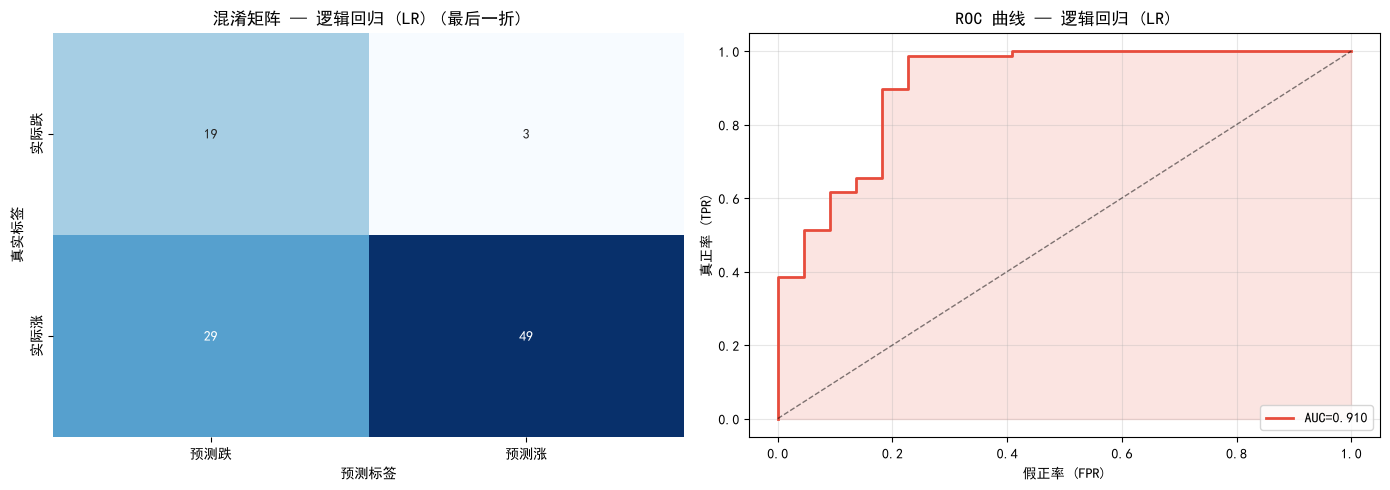

✔ 逻辑回归 (LR) 混淆矩阵 & ROC 已保存


In [9]:
# =====================================================
#  逻辑回归 (LR) — 评估指标 & 混淆矩阵 & ROC
# =====================================================
name = "逻辑回归 (LR)"
fm = all_results[name]["fold_metrics"]
print("=" * 50)
print(f"\U0001f4ca {name} \u2014 5 \u6298\u4ea4\u53c9\u9a8c\u8bc1")
print("=" * 50)
for fold_idx, m in enumerate(fm):
    print(f"  Fold {fold_idx+1}: Acc={m['Accuracy']:.3f}  P={m['Precision']:.3f}  "
          f"R={m['Recall']:.3f}  F1={m['F1']:.3f}  AUC={m['AUC']:.3f}")
avg = pd.DataFrame(fm).mean()
print(f"\n  >>> \u5747\u503c: Acc={avg['Accuracy']:.3f}  F1={avg['F1']:.3f}  AUC={avg['AUC']:.3f}")

y_pred = all_results[name]["preds"][-1]
y_prob = all_results[name]["probs"][-1]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
cm = confusion_matrix(final_y_test, y_pred)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=axes[0],
            xticklabels=["\u9884\u6d4b\u8dcc", "\u9884\u6d4b\u6da8"],
            yticklabels=["\u5b9e\u9645\u8dcc", "\u5b9e\u9645\u6da8"], cbar=False)
axes[0].set_title(f"\u6df7\u6dc6\u77e9\u9635 \u2014 {name} (\u6700\u540e\u4e00\u6298)", fontsize=12, fontweight="bold")
axes[0].set_ylabel("\u771f\u5b9e\u6807\u7b7e"); axes[0].set_xlabel("\u9884\u6d4b\u6807\u7b7e")

if not np.isnan(y_prob).all():
    fpr, tpr, _ = roc_curve(final_y_test, y_prob)
    auc_val = roc_auc_score(final_y_test, y_prob)
    axes[1].plot(fpr, tpr, lw=2, color="#E74C3C", label=f"AUC={auc_val:.3f}")
    axes[1].fill_between(fpr, tpr, alpha=0.15, color="#E74C3C")
    print(f"  AUC (最后一折) = {auc_val:.4f}")
axes[1].plot([0, 1], [0, 1], "k--", lw=1, alpha=0.5)
axes[1].set_xlabel("\u5047\u6b63\u7387 (FPR)"); axes[1].set_ylabel("\u771f\u6b63\u7387 (TPR)")
axes[1].set_title(f"ROC \u66f2\u7ebf \u2014 {name}", fontsize=12, fontweight="bold")
axes[1].legend(loc="lower right"); axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "figures" / f"confusion_roc_LR.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"\u2714 {name} \u6df7\u6dc6\u77e9\u9635 & ROC \u5df2\u4fdd\u5b58")


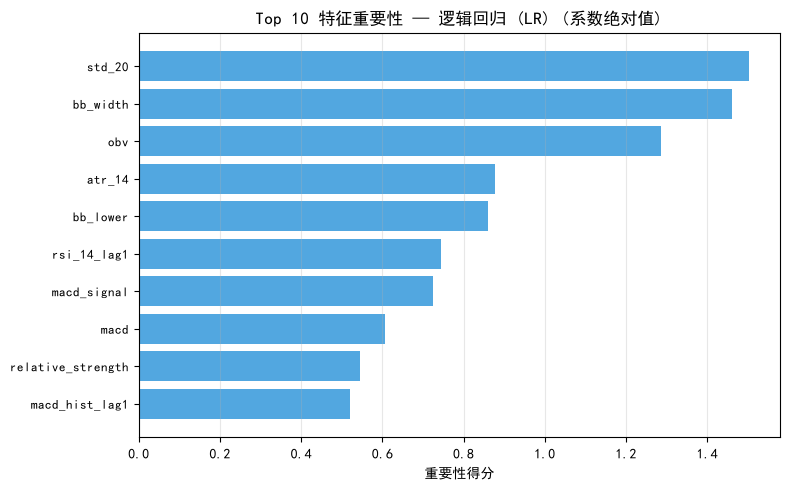


🔑 逻辑回归 (LR) — Top 10 特征
  # 10  macd_hist_lag1             0.5199
  #  9  relative_strength          0.5451
  #  8  macd                       0.6077
  #  7  macd_signal                0.7246
  #  6  rsi_14_lag1                0.7441
  #  5  bb_lower                   0.8605
  #  4  atr_14                     0.8783
  #  3  obv                        1.2869
  #  2  bb_width                   1.4600
  #  1  std_20                     1.5042


In [10]:
# =====================================================
#  逻辑回归 (LR) — 特征重要性
# =====================================================
name = "逻辑回归 (LR)"
model = final_models[name]
_, do_scale = [(n, d) for n, _, d in classifiers if n == name][0]

train_idx, test_idx = list(tscv.split(X))[-1]
_, X_te = X[train_idx], X[test_idx]

if do_scale:
    X_te = StandardScaler().fit_transform(X_te)

if name in ("\u903b\u8f91\u56de\u5f52 (LR)", "\u652f\u6301\u5411\u91cf\u673a (SVC)"):
    coef = np.abs(model.coef_[0])
    imp = pd.DataFrame(dict(feature=X_cols, importance=coef)).sort_values("importance", ascending=False)
    method = "\u7cfb\u6570\u7edd\u5bf9\u503c"
else:
    imp = pd.DataFrame(dict(feature=X_cols, importance=model.feature_importances_)).sort_values("importance", ascending=False)
    method = "\u5185\u7f6e\u91cd\u8981\u6027"

imp["rank"] = range(1, len(imp) + 1)
fig, ax = plt.subplots(figsize=(8, 5))
top = imp.head(10).iloc[::-1]
ax.barh(range(len(top)), top["importance"].values, color="#3498DB", alpha=0.85)
ax.set_yticks(range(len(top)))
ax.set_yticklabels(top["feature"].values, fontsize=9)
ax.set_title(f"Top 10 \u7279\u5f81\u91cd\u8981\u6027 \u2014 {name} ({method})", fontsize=12, fontweight="bold")
ax.set_xlabel("\u91cd\u8981\u6027\u5f97\u5206"); ax.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "figures" / f"feature_imp_LR.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"\n\U0001f511 {name} \u2014 Top 10 \u7279\u5f81")
for _, r in top.iterrows():
    print(f"  #\u2003{int(r['rank']):2d}  {r['feature']:25s}  {r['importance']:.4f}")


📈 逻辑回归 (LR) — 模拟交易策略
  年化收益率: +572.00%
  夏普比率:    +4.020
  最大回撤:   -11.25%
  胜率:       81.82%


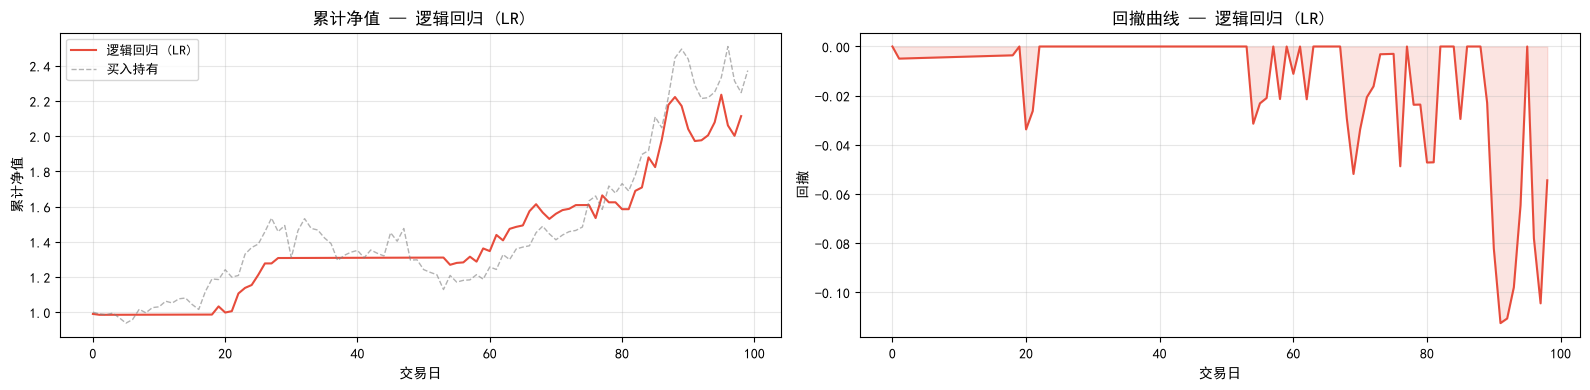

In [11]:
# =====================================================
#  逻辑回归 (LR) — 模拟交易
# =====================================================
name = "逻辑回归 (LR)"
y_pred = all_results[name]["preds"][-1]
sim = simulate_trading(final_y_test, y_pred, test_close, RISK_FREE)
sim_results[name] = sim

print("=" * 50)
print(f"\U0001f4c8 {name} \u2014 \u6a21\u62df\u4ea4\u6613\u7b56\u7565")
print("=" * 50)
print(f"  \u5e74\u5316\u6536\u76ca\u7387: {sim['ann']:>+7.2%}")
print(f"  \u590f\u666e\u6bd4\u7387:   {sim['sharpe']:>+7.3f}")
print(f"  \u6700\u5927\u56de\u64a4:   {sim['max_dd']:>7.2%}")
print(f"  \u80dc\u7387:       {sim['win']:>6.2%}")

fig, axes = plt.subplots(1, 2, figsize=(16, 4))
axes[0].plot(sim["cum"], color="#E74C3C", lw=1.5, label=name)
axes[0].plot(test_close / test_close[0], "--", color="gray", lw=1, alpha=0.6, label="\u4e70\u5165\u6301\u6709")
axes[0].set_title(f"\u7d2f\u8ba1\u51c0\u503c \u2014 {name}", fontsize=12, fontweight="bold")
axes[0].set_xlabel("\u4ea4\u6613\u65e5"); axes[0].set_ylabel("\u7d2f\u8ba1\u51c0\u503c")
axes[0].legend(fontsize=9); axes[0].grid(True, alpha=0.3)

axes[1].plot(sim["dd"], color="#E74C3C", lw=1.5)
axes[1].set_title(f"\u56de\u64a4\u66f2\u7ebf \u2014 {name}", fontsize=12, fontweight="bold")
axes[1].set_xlabel("\u4ea4\u6613\u65e5"); axes[1].set_ylabel("\u56de\u64a4")
axes[1].fill_between(range(len(sim["dd"])), sim["dd"], 0, alpha=0.15, color="#E74C3C")
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "figures" / f"equity_LR.png", dpi=150, bbox_inches="tight")
plt.show()


## 模型分析 — 随机森林 (RF)

对 随机森林 (RF) 进行单独的评估分析，包括混淆矩阵、ROC 曲线、特征重要性和模拟交易。

📊 随机森林 (RF) — 5 折交叉验证
  Fold 1: Acc=0.800  P=1.000  R=0.091  F1=0.167  AUC=0.450
  Fold 2: Acc=0.410  P=0.410  R=1.000  F1=0.582  AUC=0.582
  Fold 3: Acc=0.560  P=0.730  R=0.443  F1=0.551  AUC=0.659
  Fold 4: Acc=0.370  P=1.000  R=0.100  F1=0.182  AUC=0.577
  Fold 5: Acc=0.760  P=0.776  R=0.974  F1=0.864  AUC=0.571

  >>> 均值: Acc=0.580  F1=0.469  AUC=0.568
  AUC (最后一折) = 0.5705


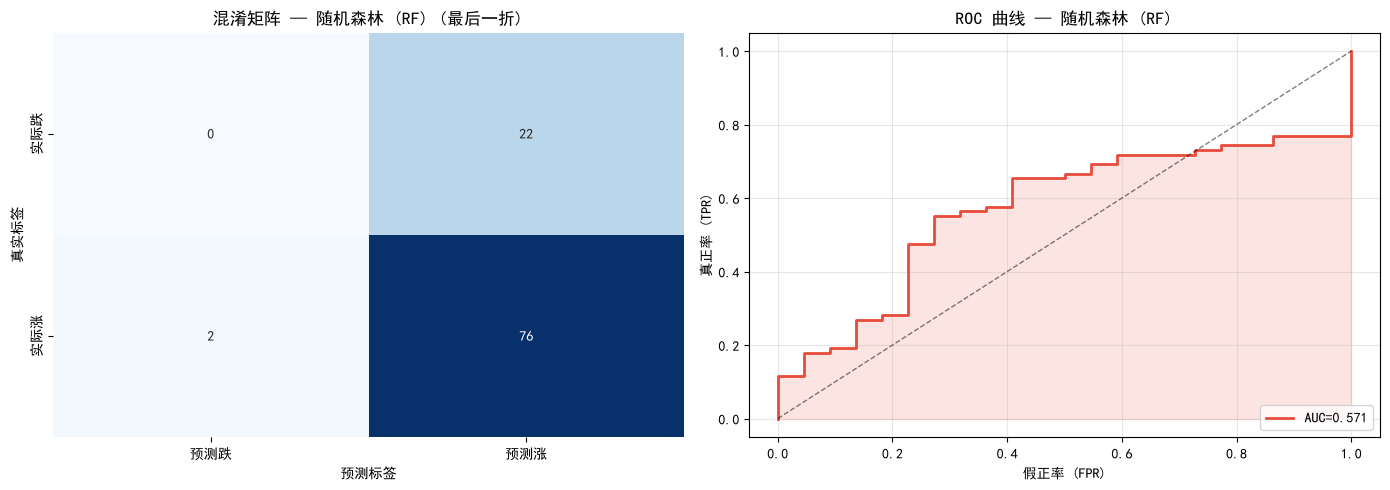

✔ 随机森林 (RF) 混淆矩阵 & ROC 已保存


In [12]:
# =====================================================
#  随机森林 (RF) — 评估指标 & 混淆矩阵 & ROC
# =====================================================
name = "随机森林 (RF)"
fm = all_results[name]["fold_metrics"]
print("=" * 50)
print(f"\U0001f4ca {name} \u2014 5 \u6298\u4ea4\u53c9\u9a8c\u8bc1")
print("=" * 50)
for fold_idx, m in enumerate(fm):
    print(f"  Fold {fold_idx+1}: Acc={m['Accuracy']:.3f}  P={m['Precision']:.3f}  "
          f"R={m['Recall']:.3f}  F1={m['F1']:.3f}  AUC={m['AUC']:.3f}")
avg = pd.DataFrame(fm).mean()
print(f"\n  >>> \u5747\u503c: Acc={avg['Accuracy']:.3f}  F1={avg['F1']:.3f}  AUC={avg['AUC']:.3f}")

y_pred = all_results[name]["preds"][-1]
y_prob = all_results[name]["probs"][-1]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
cm = confusion_matrix(final_y_test, y_pred)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=axes[0],
            xticklabels=["\u9884\u6d4b\u8dcc", "\u9884\u6d4b\u6da8"],
            yticklabels=["\u5b9e\u9645\u8dcc", "\u5b9e\u9645\u6da8"], cbar=False)
axes[0].set_title(f"\u6df7\u6dc6\u77e9\u9635 \u2014 {name} (\u6700\u540e\u4e00\u6298)", fontsize=12, fontweight="bold")
axes[0].set_ylabel("\u771f\u5b9e\u6807\u7b7e"); axes[0].set_xlabel("\u9884\u6d4b\u6807\u7b7e")

if not np.isnan(y_prob).all():
    fpr, tpr, _ = roc_curve(final_y_test, y_prob)
    auc_val = roc_auc_score(final_y_test, y_prob)
    axes[1].plot(fpr, tpr, lw=2, color="#E74C3C", label=f"AUC={auc_val:.3f}")
    axes[1].fill_between(fpr, tpr, alpha=0.15, color="#E74C3C")
    print(f"  AUC (最后一折) = {auc_val:.4f}")
axes[1].plot([0, 1], [0, 1], "k--", lw=1, alpha=0.5)
axes[1].set_xlabel("\u5047\u6b63\u7387 (FPR)"); axes[1].set_ylabel("\u771f\u6b63\u7387 (TPR)")
axes[1].set_title(f"ROC \u66f2\u7ebf \u2014 {name}", fontsize=12, fontweight="bold")
axes[1].legend(loc="lower right"); axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "figures" / f"confusion_roc_RF.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"\u2714 {name} \u6df7\u6dc6\u77e9\u9635 & ROC \u5df2\u4fdd\u5b58")


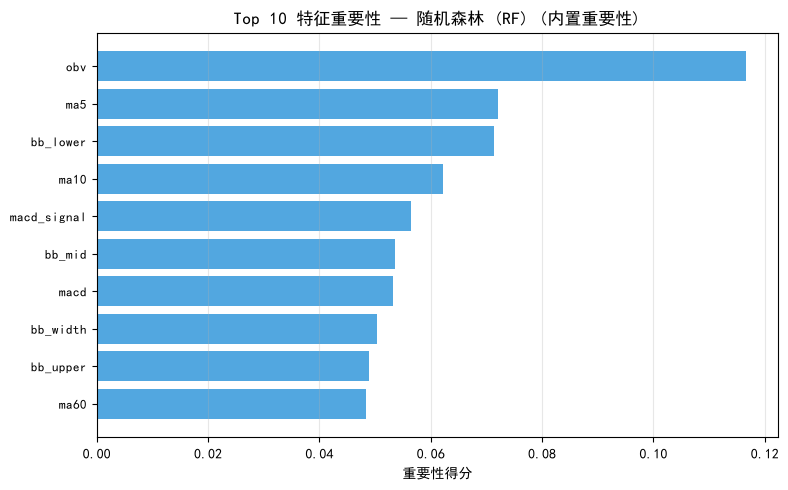


🔑 随机森林 (RF) — Top 10 特征
  # 10  ma60                       0.0484
  #  9  bb_upper                   0.0489
  #  8  bb_width                   0.0503
  #  7  macd                       0.0532
  #  6  bb_mid                     0.0537
  #  5  macd_signal                0.0565
  #  4  ma10                       0.0623
  #  3  bb_lower                   0.0714
  #  2  ma5                        0.0720
  #  1  obv                        0.1165


In [13]:
# =====================================================
#  随机森林 (RF) — 特征重要性
# =====================================================
name = "随机森林 (RF)"
model = final_models[name]
_, do_scale = [(n, d) for n, _, d in classifiers if n == name][0]

train_idx, test_idx = list(tscv.split(X))[-1]
_, X_te = X[train_idx], X[test_idx]

if do_scale:
    X_te = StandardScaler().fit_transform(X_te)

if name in ("\u903b\u8f91\u56de\u5f52 (LR)", "\u652f\u6301\u5411\u91cf\u673a (SVC)"):
    coef = np.abs(model.coef_[0])
    imp = pd.DataFrame(dict(feature=X_cols, importance=coef)).sort_values("importance", ascending=False)
    method = "\u7cfb\u6570\u7edd\u5bf9\u503c"
else:
    imp = pd.DataFrame(dict(feature=X_cols, importance=model.feature_importances_)).sort_values("importance", ascending=False)
    method = "\u5185\u7f6e\u91cd\u8981\u6027"

imp["rank"] = range(1, len(imp) + 1)
fig, ax = plt.subplots(figsize=(8, 5))
top = imp.head(10).iloc[::-1]
ax.barh(range(len(top)), top["importance"].values, color="#3498DB", alpha=0.85)
ax.set_yticks(range(len(top)))
ax.set_yticklabels(top["feature"].values, fontsize=9)
ax.set_title(f"Top 10 \u7279\u5f81\u91cd\u8981\u6027 \u2014 {name} ({method})", fontsize=12, fontweight="bold")
ax.set_xlabel("\u91cd\u8981\u6027\u5f97\u5206"); ax.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "figures" / f"feature_imp_RF.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"\n\U0001f511 {name} \u2014 Top 10 \u7279\u5f81")
for _, r in top.iterrows():
    print(f"  #\u2003{int(r['rank']):2d}  {r['feature']:25s}  {r['importance']:.4f}")


📈 随机森林 (RF) — 模拟交易策略
  年化收益率: +857.21%
  夏普比率:    +3.387
  最大回撤:   -26.44%
  胜率:       59.60%


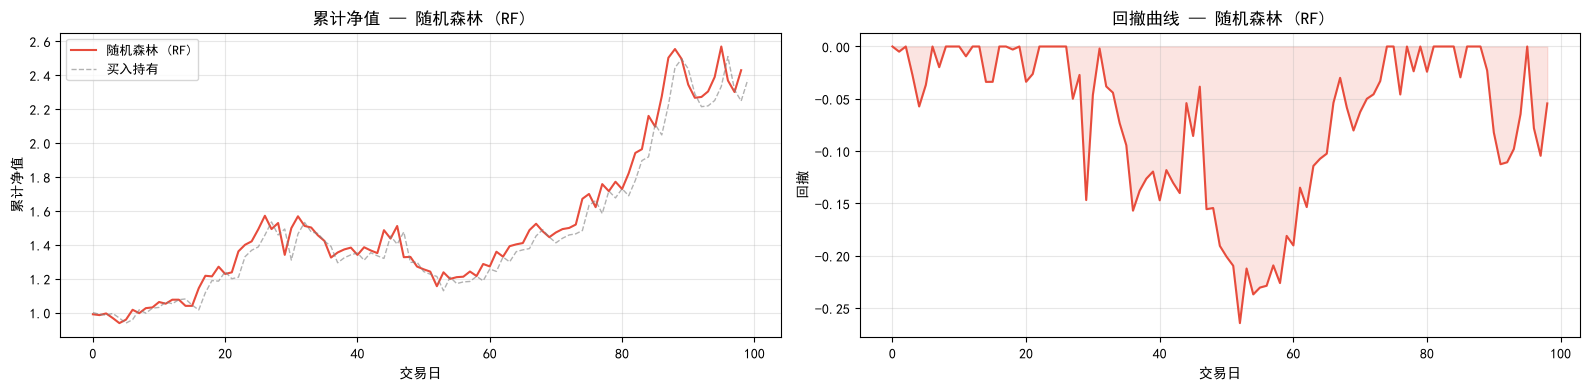

In [14]:
# =====================================================
#  随机森林 (RF) — 模拟交易
# =====================================================
name = "随机森林 (RF)"
y_pred = all_results[name]["preds"][-1]
sim = simulate_trading(final_y_test, y_pred, test_close, RISK_FREE)
sim_results[name] = sim

print("=" * 50)
print(f"\U0001f4c8 {name} \u2014 \u6a21\u62df\u4ea4\u6613\u7b56\u7565")
print("=" * 50)
print(f"  \u5e74\u5316\u6536\u76ca\u7387: {sim['ann']:>+7.2%}")
print(f"  \u590f\u666e\u6bd4\u7387:   {sim['sharpe']:>+7.3f}")
print(f"  \u6700\u5927\u56de\u64a4:   {sim['max_dd']:>7.2%}")
print(f"  \u80dc\u7387:       {sim['win']:>6.2%}")

fig, axes = plt.subplots(1, 2, figsize=(16, 4))
axes[0].plot(sim["cum"], color="#E74C3C", lw=1.5, label=name)
axes[0].plot(test_close / test_close[0], "--", color="gray", lw=1, alpha=0.6, label="\u4e70\u5165\u6301\u6709")
axes[0].set_title(f"\u7d2f\u8ba1\u51c0\u503c \u2014 {name}", fontsize=12, fontweight="bold")
axes[0].set_xlabel("\u4ea4\u6613\u65e5"); axes[0].set_ylabel("\u7d2f\u8ba1\u51c0\u503c")
axes[0].legend(fontsize=9); axes[0].grid(True, alpha=0.3)

axes[1].plot(sim["dd"], color="#E74C3C", lw=1.5)
axes[1].set_title(f"\u56de\u64a4\u66f2\u7ebf \u2014 {name}", fontsize=12, fontweight="bold")
axes[1].set_xlabel("\u4ea4\u6613\u65e5"); axes[1].set_ylabel("\u56de\u64a4")
axes[1].fill_between(range(len(sim["dd"])), sim["dd"], 0, alpha=0.15, color="#E74C3C")
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "figures" / f"equity_RF.png", dpi=150, bbox_inches="tight")
plt.show()


## 模型分析 — XGBoost

对 XGBoost 进行单独的评估分析，包括混淆矩阵、ROC 曲线、特征重要性和模拟交易。

📊 XGBoost — 5 折交叉验证
  Fold 1: Acc=0.780  P=0.000  R=0.000  F1=0.000  AUC=0.556
  Fold 2: Acc=0.410  P=0.410  R=1.000  F1=0.582  AUC=0.418
  Fold 3: Acc=0.550  P=0.750  R=0.393  F1=0.516  AUC=0.625
  Fold 4: Acc=0.340  P=1.000  R=0.057  F1=0.108  AUC=0.597
  Fold 5: Acc=0.710  P=0.788  R=0.859  F1=0.822  AUC=0.670

  >>> 均值: Acc=0.558  F1=0.406  AUC=0.573
  AUC (最后一折) = 0.6702


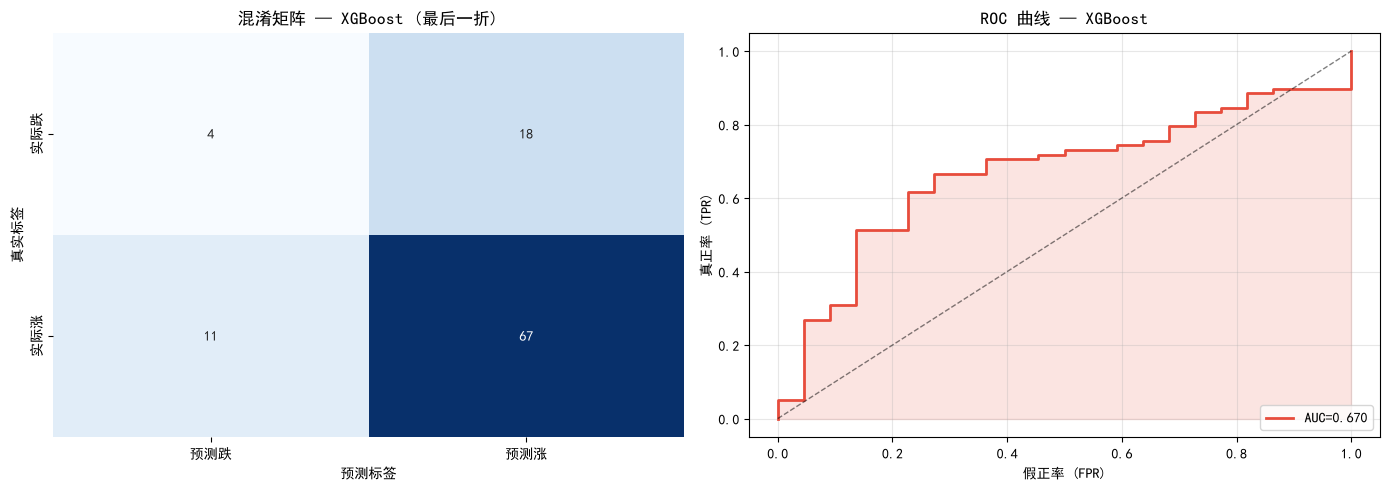

✔ XGBoost 混淆矩阵 & ROC 已保存


In [15]:
# =====================================================
#  XGBoost — 评估指标 & 混淆矩阵 & ROC
# =====================================================
name = "XGBoost"
fm = all_results[name]["fold_metrics"]
print("=" * 50)
print(f"\U0001f4ca {name} \u2014 5 \u6298\u4ea4\u53c9\u9a8c\u8bc1")
print("=" * 50)
for fold_idx, m in enumerate(fm):
    print(f"  Fold {fold_idx+1}: Acc={m['Accuracy']:.3f}  P={m['Precision']:.3f}  "
          f"R={m['Recall']:.3f}  F1={m['F1']:.3f}  AUC={m['AUC']:.3f}")
avg = pd.DataFrame(fm).mean()
print(f"\n  >>> \u5747\u503c: Acc={avg['Accuracy']:.3f}  F1={avg['F1']:.3f}  AUC={avg['AUC']:.3f}")

y_pred = all_results[name]["preds"][-1]
y_prob = all_results[name]["probs"][-1]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
cm = confusion_matrix(final_y_test, y_pred)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=axes[0],
            xticklabels=["\u9884\u6d4b\u8dcc", "\u9884\u6d4b\u6da8"],
            yticklabels=["\u5b9e\u9645\u8dcc", "\u5b9e\u9645\u6da8"], cbar=False)
axes[0].set_title(f"\u6df7\u6dc6\u77e9\u9635 \u2014 {name} (\u6700\u540e\u4e00\u6298)", fontsize=12, fontweight="bold")
axes[0].set_ylabel("\u771f\u5b9e\u6807\u7b7e"); axes[0].set_xlabel("\u9884\u6d4b\u6807\u7b7e")

if not np.isnan(y_prob).all():
    fpr, tpr, _ = roc_curve(final_y_test, y_prob)
    auc_val = roc_auc_score(final_y_test, y_prob)
    axes[1].plot(fpr, tpr, lw=2, color="#E74C3C", label=f"AUC={auc_val:.3f}")
    axes[1].fill_between(fpr, tpr, alpha=0.15, color="#E74C3C")
    print(f"  AUC (最后一折) = {auc_val:.4f}")
axes[1].plot([0, 1], [0, 1], "k--", lw=1, alpha=0.5)
axes[1].set_xlabel("\u5047\u6b63\u7387 (FPR)"); axes[1].set_ylabel("\u771f\u6b63\u7387 (TPR)")
axes[1].set_title(f"ROC \u66f2\u7ebf \u2014 {name}", fontsize=12, fontweight="bold")
axes[1].legend(loc="lower right"); axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "figures" / f"confusion_roc_XGB.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"\u2714 {name} \u6df7\u6dc6\u77e9\u9635 & ROC \u5df2\u4fdd\u5b58")


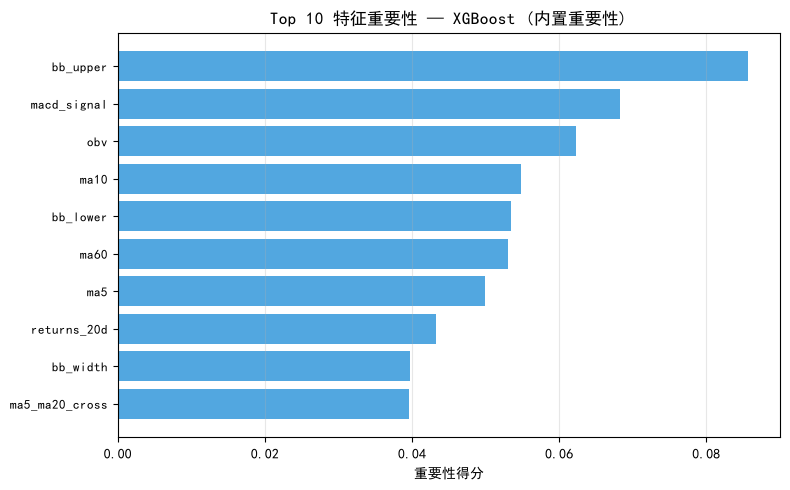


🔑 XGBoost — Top 10 特征
  # 10  ma5_ma20_cross             0.0397
  #  9  bb_width                   0.0398
  #  8  returns_20d                0.0433
  #  7  ma5                        0.0499
  #  6  ma60                       0.0531
  #  5  bb_lower                   0.0534
  #  4  ma10                       0.0549
  #  3  obv                        0.0624
  #  2  macd_signal                0.0682
  #  1  bb_upper                   0.0857


In [16]:
# =====================================================
#  XGBoost — 特征重要性
# =====================================================
name = "XGBoost"
model = final_models[name]
_, do_scale = [(n, d) for n, _, d in classifiers if n == name][0]

train_idx, test_idx = list(tscv.split(X))[-1]
_, X_te = X[train_idx], X[test_idx]

if do_scale:
    X_te = StandardScaler().fit_transform(X_te)

if name in ("\u903b\u8f91\u56de\u5f52 (LR)", "\u652f\u6301\u5411\u91cf\u673a (SVC)"):
    coef = np.abs(model.coef_[0])
    imp = pd.DataFrame(dict(feature=X_cols, importance=coef)).sort_values("importance", ascending=False)
    method = "\u7cfb\u6570\u7edd\u5bf9\u503c"
else:
    imp = pd.DataFrame(dict(feature=X_cols, importance=model.feature_importances_)).sort_values("importance", ascending=False)
    method = "\u5185\u7f6e\u91cd\u8981\u6027"

imp["rank"] = range(1, len(imp) + 1)
fig, ax = plt.subplots(figsize=(8, 5))
top = imp.head(10).iloc[::-1]
ax.barh(range(len(top)), top["importance"].values, color="#3498DB", alpha=0.85)
ax.set_yticks(range(len(top)))
ax.set_yticklabels(top["feature"].values, fontsize=9)
ax.set_title(f"Top 10 \u7279\u5f81\u91cd\u8981\u6027 \u2014 {name} ({method})", fontsize=12, fontweight="bold")
ax.set_xlabel("\u91cd\u8981\u6027\u5f97\u5206"); ax.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "figures" / f"feature_imp_XGB.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"\n\U0001f511 {name} \u2014 Top 10 \u7279\u5f81")
for _, r in top.iterrows():
    print(f"  #\u2003{int(r['rank']):2d}  {r['feature']:25s}  {r['importance']:.4f}")


📈 XGBoost — 模拟交易策略
  年化收益率: +787.63%
  夏普比率:    +3.399
  最大回撤:   -24.28%
  胜率:       66.67%


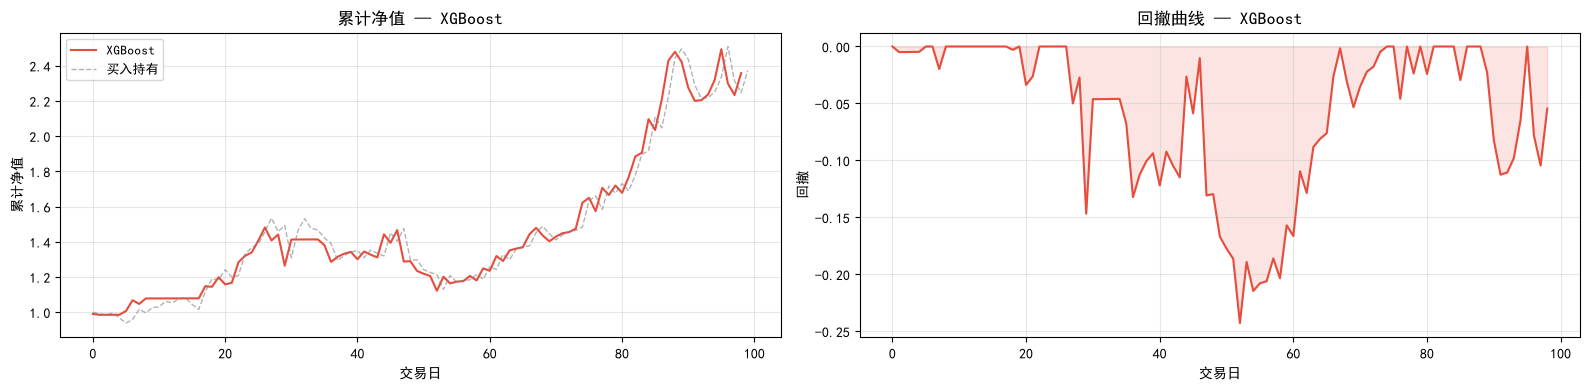

In [17]:
# =====================================================
#  XGBoost — 模拟交易
# =====================================================
name = "XGBoost"
y_pred = all_results[name]["preds"][-1]
sim = simulate_trading(final_y_test, y_pred, test_close, RISK_FREE)
sim_results[name] = sim

print("=" * 50)
print(f"\U0001f4c8 {name} \u2014 \u6a21\u62df\u4ea4\u6613\u7b56\u7565")
print("=" * 50)
print(f"  \u5e74\u5316\u6536\u76ca\u7387: {sim['ann']:>+7.2%}")
print(f"  \u590f\u666e\u6bd4\u7387:   {sim['sharpe']:>+7.3f}")
print(f"  \u6700\u5927\u56de\u64a4:   {sim['max_dd']:>7.2%}")
print(f"  \u80dc\u7387:       {sim['win']:>6.2%}")

fig, axes = plt.subplots(1, 2, figsize=(16, 4))
axes[0].plot(sim["cum"], color="#E74C3C", lw=1.5, label=name)
axes[0].plot(test_close / test_close[0], "--", color="gray", lw=1, alpha=0.6, label="\u4e70\u5165\u6301\u6709")
axes[0].set_title(f"\u7d2f\u8ba1\u51c0\u503c \u2014 {name}", fontsize=12, fontweight="bold")
axes[0].set_xlabel("\u4ea4\u6613\u65e5"); axes[0].set_ylabel("\u7d2f\u8ba1\u51c0\u503c")
axes[0].legend(fontsize=9); axes[0].grid(True, alpha=0.3)

axes[1].plot(sim["dd"], color="#E74C3C", lw=1.5)
axes[1].set_title(f"\u56de\u64a4\u66f2\u7ebf \u2014 {name}", fontsize=12, fontweight="bold")
axes[1].set_xlabel("\u4ea4\u6613\u65e5"); axes[1].set_ylabel("\u56de\u64a4")
axes[1].fill_between(range(len(sim["dd"])), sim["dd"], 0, alpha=0.15, color="#E74C3C")
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "figures" / f"equity_XGB.png", dpi=150, bbox_inches="tight")
plt.show()


## 模型分析 — 支持向量机 (SVC)

对 支持向量机 (SVC) 进行单独的评估分析，包括混淆矩阵、ROC 曲线、特征重要性和模拟交易。

📊 支持向量机 (SVC) — 5 折交叉验证
  Fold 1: Acc=0.780  P=0.000  R=0.000  F1=0.000  AUC=0.797
  Fold 2: Acc=0.470  P=0.435  R=0.976  F1=0.602  AUC=0.766
  Fold 3: Acc=0.470  P=0.618  R=0.344  F1=0.442  AUC=0.556
  Fold 4: Acc=0.300  P=0.000  R=0.000  F1=0.000  AUC=0.435
  Fold 5: Acc=0.740  P=0.933  R=0.718  F1=0.812  AUC=0.916

  >>> 均值: Acc=0.552  F1=0.371  AUC=0.694
  AUC (最后一折) = 0.9161


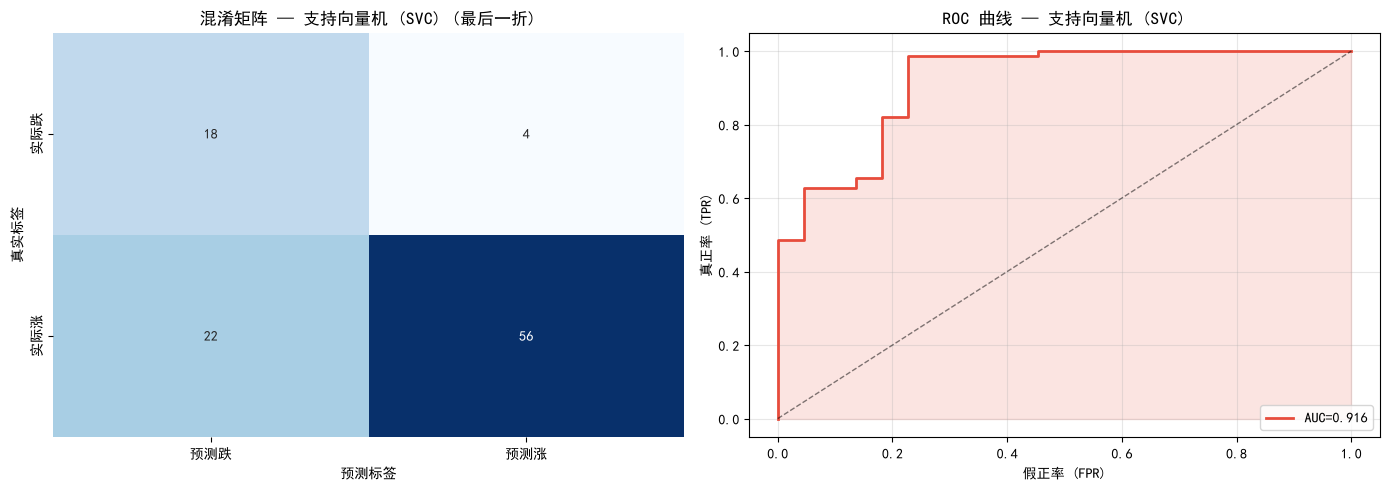

✔ 支持向量机 (SVC) 混淆矩阵 & ROC 已保存


In [18]:
# =====================================================
#  支持向量机 (SVC) — 评估指标 & 混淆矩阵 & ROC
# =====================================================
name = "支持向量机 (SVC)"
fm = all_results[name]["fold_metrics"]
print("=" * 50)
print(f"\U0001f4ca {name} \u2014 5 \u6298\u4ea4\u53c9\u9a8c\u8bc1")
print("=" * 50)
for fold_idx, m in enumerate(fm):
    print(f"  Fold {fold_idx+1}: Acc={m['Accuracy']:.3f}  P={m['Precision']:.3f}  "
          f"R={m['Recall']:.3f}  F1={m['F1']:.3f}  AUC={m['AUC']:.3f}")
avg = pd.DataFrame(fm).mean()
print(f"\n  >>> \u5747\u503c: Acc={avg['Accuracy']:.3f}  F1={avg['F1']:.3f}  AUC={avg['AUC']:.3f}")

y_pred = all_results[name]["preds"][-1]
y_prob = all_results[name]["probs"][-1]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
cm = confusion_matrix(final_y_test, y_pred)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=axes[0],
            xticklabels=["\u9884\u6d4b\u8dcc", "\u9884\u6d4b\u6da8"],
            yticklabels=["\u5b9e\u9645\u8dcc", "\u5b9e\u9645\u6da8"], cbar=False)
axes[0].set_title(f"\u6df7\u6dc6\u77e9\u9635 \u2014 {name} (\u6700\u540e\u4e00\u6298)", fontsize=12, fontweight="bold")
axes[0].set_ylabel("\u771f\u5b9e\u6807\u7b7e"); axes[0].set_xlabel("\u9884\u6d4b\u6807\u7b7e")

if not np.isnan(y_prob).all():
    fpr, tpr, _ = roc_curve(final_y_test, y_prob)
    auc_val = roc_auc_score(final_y_test, y_prob)
    axes[1].plot(fpr, tpr, lw=2, color="#E74C3C", label=f"AUC={auc_val:.3f}")
    axes[1].fill_between(fpr, tpr, alpha=0.15, color="#E74C3C")
    print(f"  AUC (最后一折) = {auc_val:.4f}")
axes[1].plot([0, 1], [0, 1], "k--", lw=1, alpha=0.5)
axes[1].set_xlabel("\u5047\u6b63\u7387 (FPR)"); axes[1].set_ylabel("\u771f\u6b63\u7387 (TPR)")
axes[1].set_title(f"ROC \u66f2\u7ebf \u2014 {name}", fontsize=12, fontweight="bold")
axes[1].legend(loc="lower right"); axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "figures" / f"confusion_roc_SVC.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"\u2714 {name} \u6df7\u6dc6\u77e9\u9635 & ROC \u5df2\u4fdd\u5b58")


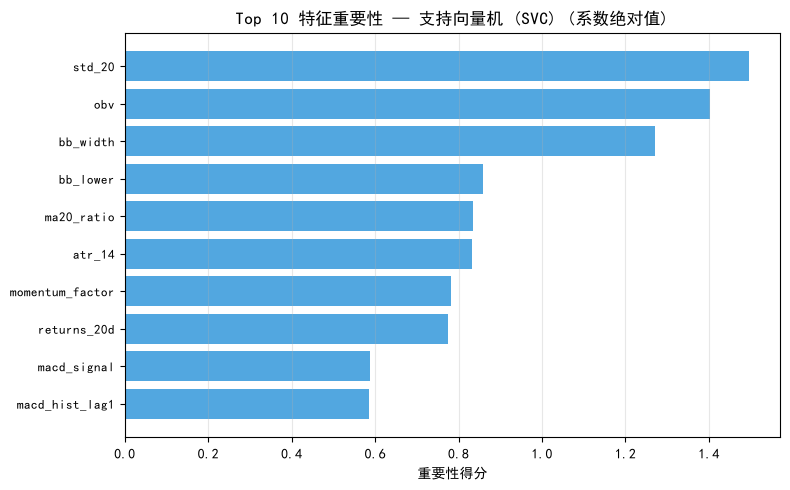


🔑 支持向量机 (SVC) — Top 10 特征
  # 10  macd_hist_lag1             0.5863
  #  9  macd_signal                0.5870
  #  8  returns_20d                0.7753
  #  7  momentum_factor            0.7824
  #  6  atr_14                     0.8330
  #  5  ma20_ratio                 0.8344
  #  4  bb_lower                   0.8582
  #  3  bb_width                   1.2699
  #  2  obv                        1.4015
  #  1  std_20                     1.4957


In [19]:
# =====================================================
#  支持向量机 (SVC) — 特征重要性
# =====================================================
name = "支持向量机 (SVC)"
model = final_models[name]
_, do_scale = [(n, d) for n, _, d in classifiers if n == name][0]

train_idx, test_idx = list(tscv.split(X))[-1]
_, X_te = X[train_idx], X[test_idx]

if do_scale:
    X_te = StandardScaler().fit_transform(X_te)

if name in ("\u903b\u8f91\u56de\u5f52 (LR)", "\u652f\u6301\u5411\u91cf\u673a (SVC)"):
    coef = np.abs(model.coef_[0])
    imp = pd.DataFrame(dict(feature=X_cols, importance=coef)).sort_values("importance", ascending=False)
    method = "\u7cfb\u6570\u7edd\u5bf9\u503c"
else:
    imp = pd.DataFrame(dict(feature=X_cols, importance=model.feature_importances_)).sort_values("importance", ascending=False)
    method = "\u5185\u7f6e\u91cd\u8981\u6027"

imp["rank"] = range(1, len(imp) + 1)
fig, ax = plt.subplots(figsize=(8, 5))
top = imp.head(10).iloc[::-1]
ax.barh(range(len(top)), top["importance"].values, color="#3498DB", alpha=0.85)
ax.set_yticks(range(len(top)))
ax.set_yticklabels(top["feature"].values, fontsize=9)
ax.set_title(f"Top 10 \u7279\u5f81\u91cd\u8981\u6027 \u2014 {name} ({method})", fontsize=12, fontweight="bold")
ax.set_xlabel("\u91cd\u8981\u6027\u5f97\u5206"); ax.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "figures" / f"feature_imp_SVC.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"\n\U0001f511 {name} \u2014 Top 10 \u7279\u5f81")
for _, r in top.iterrows():
    print(f"  #\u2003{int(r['rank']):2d}  {r['feature']:25s}  {r['importance']:.4f}")


📈 支持向量机 (SVC) — 模拟交易策略
  年化收益率: +1047.71%
  夏普比率:    +4.734
  最大回撤:   -11.25%
  胜率:       79.80%


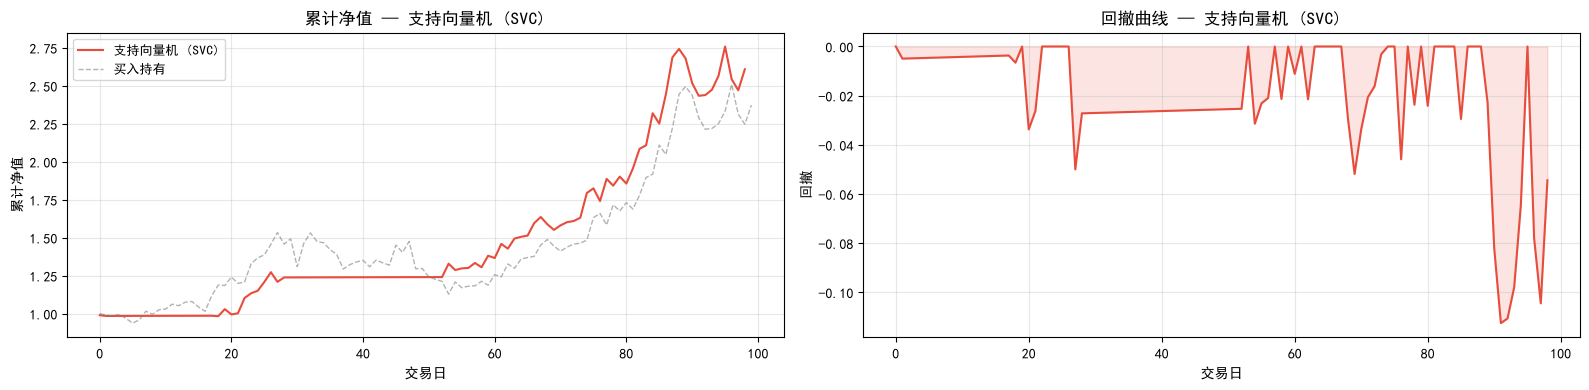

In [20]:
# =====================================================
#  支持向量机 (SVC) — 模拟交易
# =====================================================
name = "支持向量机 (SVC)"
y_pred = all_results[name]["preds"][-1]
sim = simulate_trading(final_y_test, y_pred, test_close, RISK_FREE)
sim_results[name] = sim

print("=" * 50)
print(f"\U0001f4c8 {name} \u2014 \u6a21\u62df\u4ea4\u6613\u7b56\u7565")
print("=" * 50)
print(f"  \u5e74\u5316\u6536\u76ca\u7387: {sim['ann']:>+7.2%}")
print(f"  \u590f\u666e\u6bd4\u7387:   {sim['sharpe']:>+7.3f}")
print(f"  \u6700\u5927\u56de\u64a4:   {sim['max_dd']:>7.2%}")
print(f"  \u80dc\u7387:       {sim['win']:>6.2%}")

fig, axes = plt.subplots(1, 2, figsize=(16, 4))
axes[0].plot(sim["cum"], color="#E74C3C", lw=1.5, label=name)
axes[0].plot(test_close / test_close[0], "--", color="gray", lw=1, alpha=0.6, label="\u4e70\u5165\u6301\u6709")
axes[0].set_title(f"\u7d2f\u8ba1\u51c0\u503c \u2014 {name}", fontsize=12, fontweight="bold")
axes[0].set_xlabel("\u4ea4\u6613\u65e5"); axes[0].set_ylabel("\u7d2f\u8ba1\u51c0\u503c")
axes[0].legend(fontsize=9); axes[0].grid(True, alpha=0.3)

axes[1].plot(sim["dd"], color="#E74C3C", lw=1.5)
axes[1].set_title(f"\u56de\u64a4\u66f2\u7ebf \u2014 {name}", fontsize=12, fontweight="bold")
axes[1].set_xlabel("\u4ea4\u6613\u65e5"); axes[1].set_ylabel("\u56de\u64a4")
axes[1].fill_between(range(len(sim["dd"])), sim["dd"], 0, alpha=0.15, color="#E74C3C")
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "figures" / f"equity_SVC.png", dpi=150, bbox_inches="tight")
plt.show()


## 模型横向对比

将 4 个模型的分类指标和交易指标放在一起对比，便于综合评估。

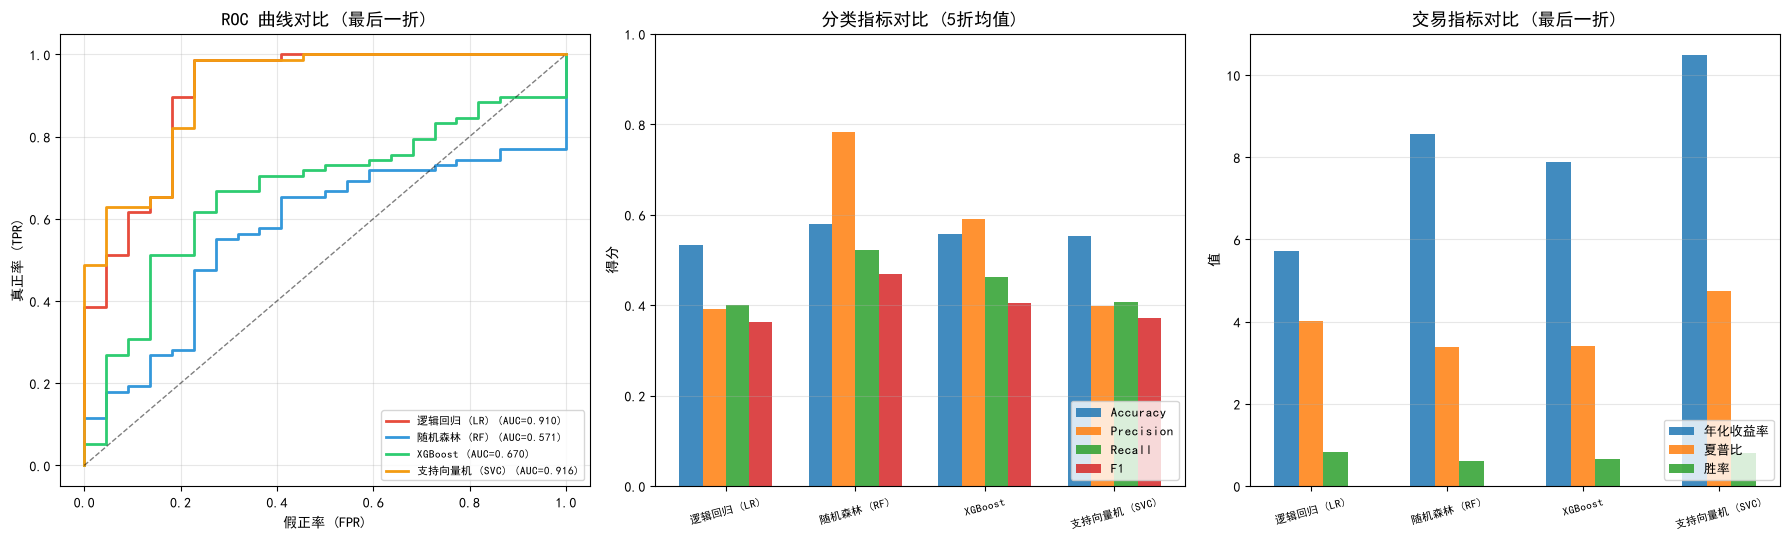

✅ 横向对比图已保存

📋 CV 指标汇总 (5折均值)
             Accuracy  Precision  Recall      F1     AUC
Model                                                   
逻辑回归 (LR)       0.534     0.3918  0.4011  0.3625  0.7124
随机森林 (RF)       0.580     0.7830  0.5216  0.4689  0.5678
XGBoost         0.558     0.5896  0.4619  0.4056  0.5732
支持向量机 (SVC)     0.552     0.3972  0.4076  0.3710  0.6939

🏆 综合最佳: 支持向量机 (SVC) (Sharpe=4.734)


In [21]:
# =====================================================
#  4 模型横向对比
# =====================================================
comparison_table = []
for name in MODEL_NAMES:
    fm = all_results[name]["fold_metrics"]
    avg = pd.DataFrame(fm).mean()
    comparison_table.append({
        "Model": name,
        "Accuracy": avg["Accuracy"],
        "Precision": avg["Precision"],
        "Recall": avg["Recall"],
        "F1": avg["F1"],
        "AUC": avg["AUC"],
    })

fig, axes = plt.subplots(1, 3, figsize=(18, 5.5))

# 图1: ROC 叠图
ax = axes[0]
colors_plot = ["#E74C3C", "#3498DB", "#2ECC71", "#F39C12"]
for idx, name in enumerate(preds_dict):
    prob = probs_dict[name]
    if np.isnan(prob).all(): continue
    fpr, tpr, _ = roc_curve(final_y_test, prob)
    auc_val = roc_auc_score(final_y_test, prob)
    ax.plot(fpr, tpr, lw=2, color=colors_plot[idx], label=f"{name} (AUC={auc_val:.3f})")
ax.plot([0, 1], [0, 1], "k--", lw=1, alpha=0.5)
ax.set_xlabel("假正率 (FPR)"); ax.set_ylabel("真正率 (TPR)")
ax.set_title("ROC 曲线对比 (最后一折)", fontsize=13, fontweight="bold")
ax.legend(loc="lower right", fontsize=8); ax.grid(True, alpha=0.3)

# 图2: 分类指标对比
ax = axes[1]
w = 0.18
x = np.arange(len(comparison_table))
for i, m in enumerate(["Accuracy", "Precision", "Recall", "F1"]):
    vals = [r[m] for r in comparison_table]
    ax.bar(x + i * w - 1.5 * w, vals, w, label=m, alpha=0.85)
ax.set_xticks(x)
ax.set_xticklabels([r["Model"] for r in comparison_table], fontsize=8, rotation=15)
ax.set_ylabel("得分"); ax.set_title("分类指标对比 (5折均值)", fontsize=13, fontweight="bold")
ax.legend(loc="lower right", fontsize=9); ax.set_ylim(0, 1); ax.grid(axis="y", alpha=0.3)

# 图3: 交易指标对比
ax = axes[2]
x2 = np.arange(len(sim_results))
for i, (fk, fl) in enumerate(zip(["ann", "sharpe", "win"], ["年化收益率", "夏普比", "胜率"])):
    vals = [sim_results[n][fk] for n in sim_results]
    ax.bar(x2 + i * w - 1 * w, vals, w, label=fl, alpha=0.85)
ax.set_xticks(x2)
ax.set_xticklabels(list(sim_results.keys()), fontsize=8, rotation=15)
ax.set_ylabel("值"); ax.set_title("交易指标对比 (最后一折)", fontsize=13, fontweight="bold")
ax.legend(loc="lower right", fontsize=9); ax.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "figures" / "model_comparison.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ 横向对比图已保存")

print("\n📋 CV 指标汇总 (5折均值)")
pdf = pd.DataFrame(comparison_table).set_index("Model").round(4)
print(pdf.to_string())

best_model = max(sim_results, key=lambda n: sim_results[n]["sharpe"])
print(f"\n🏆 综合最佳: {best_model} (Sharpe={sim_results[best_model]['sharpe']:.3f})")


In [22]:
# =====================================================
#  保存结果到 CSV
# =====================================================
pred_df = pd.DataFrame({"trade_date": test_dates, "actual": final_y_test})
for name in preds_dict:
    pred_df[f"pred_{name}"] = preds_dict[name]
    if not np.isnan(probs_dict[name]).all():
        pred_df[f"prob_{name}"] = probs_dict[name]
pred_df.to_csv(OUTPUT_DIR / "predictions" / "comparison_classification.csv", index=False)
print(f"✅ predictions/comparison_classification.csv ({len(pred_df)} 行)")

pd.DataFrame(comparison_table).set_index("Model").to_csv(
    OUTPUT_DIR / "metrics" / "classification_metrics.csv")
print("✅ metrics/classification_metrics.csv")

sim_rows = [{"Model": n, "Annualized_Return": s["ann"], "Sharpe_Ratio": s["sharpe"],
             "Max_Drawdown": s["max_dd"], "Win_Rate": s["win"]}
            for n, s in sim_results.items()]
pd.DataFrame(sim_rows).set_index("Model").to_csv(
    OUTPUT_DIR / "metrics" / "simulation_metrics.csv")
print("✅ metrics/simulation_metrics.csv")

print(f"\n📁 全部文件已保存到 Task-5/")
print(f"   ├── predictions/  (1 CSV)")
print(f"   ├── metrics/  (2 CSV)")
print(f"   └── figures/  (9 PNG)")


✅ predictions/comparison_classification.csv (100 行)
✅ metrics/classification_metrics.csv
✅ metrics/simulation_metrics.csv

📁 全部文件已保存到 Task-5/
   ├── predictions/  (1 CSV)
   ├── metrics/  (2 CSV)
   └── figures/  (9 PNG)


## 项目总结

### 完整工作流
| 步骤 | 内容 |
|------|------|
| ✅ 数据加载 | 兆易创新 2022-2026 日线数据 |
| ✅ EDA | 价格走势、涨跌分布、收益率分析 |
| ✅ 特征工程 | 36 个技术指标 + 价格衍生特征 |
| ✅ 标签构造 | 未来 20 日涨跌二分类 (分位数过滤) |
| ✅ Purged Walk-Forward CV | 5 折滚动验证 (gap=20) |
| ✅ 4 个模型独立分析 | 逻辑回归 / 随机森林 / XGBoost / SVM |
| ✅ 横向对比 | 分类指标 + 交易指标 + ROC 曲线 |
